## PEKİŞTİRMELİ ÖĞRENME İLE DONMUŞ GÖL GÖREVİ 

pekiştirmeli öğrenme : ajanın çevrede hareketler ile çevreyi öğrenmesi ve ödül gibi kavramlarla çevreden geri bildirim almasıdır 

4*4 lük matristen oluşur 4 tane kuyu bulunmakta  diğer taraflar donmuş göldür amacımız  hedef olan kareyi bulmak 

is_slipery özelliği ile örnek olarak sağa git dediğimiz ajan belirli bir olasılık ile ayağı kaymış gibi başka kareye gidebilecek 



0:Sola git
1:Aşşağı git
2:Sağa git
3:Yukarı git

### Environment Tanımı 

In [259]:
import gymnasium as gym
import random
import numpy as np



enviroment=gym.make("FrozenLake-v1",render_mode="ansi" , is_slippery=False)

enviroment.reset() # ortamı sıfırdan başlatır
print(enviroment.render()) # ortamı ekrana basar

# s startate
# f frozen
# h hole   kuyu
# g goal   ulaşılacak yer 
# o obstacle




SFFF
FHFH
FFFH
HFFG



In [260]:
number_of_states = enviroment.observation_space.n # ortamın state sayısı 4*4 16 kare

number_of_actions = enviroment.action_space.n # ortamın action sayısı 4 tane 0:sol 1:aşağı 2:sağ 3:yukarı

print("number of states:",number_of_states)
print("number of actions:",number_of_actions)

number of states: 16
number of actions: 4


#### Q Table oluşturma : states x actions
##### ajanımız bu tabloyu kullanacak doldurarak öğrenme yapacak

In [261]:
q_table=np.zeros((number_of_states,number_of_actions))
q_table  

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

In [262]:
action=enviroment.action_space.sample() # rastgele bir action seçer 0 1 2 3 
new_state , reward,done,info,_=enviroment.step(action)
#  adım sonucu dönen değerlerin ne olduğunu görmek için
print(action) # yapılan adım
print(new_state) # yeni konum
print(reward) # ödül
print(done) #bitti mi
print(info) # ek bilgi
print(enviroment.render()) # ortamı ekrana basar




0
0
0.0
False
False
  (Left)
SFFF
FHFH
FFFH
HFFG



### Q Learning Model Geliştirme - Ajan Eğitimi 

In [263]:
import matplotlib.pyplot as plt


In [264]:
enviroment1 = gym.make('FrozenLake-v1', is_slippery=False)
enviroment1.reset()

q_table1 = np.zeros((enviroment1.observation_space.n, enviroment1.action_space.n)) # 16*4



In [265]:
# hiperparametre optimizasyonu
episodes = 1000  # toplam deneme sayısı
learning_rate = 0.1  # öğrenme katsayısı
gamma = 0.9  # indirim faktörü
alpha = 0.5  # öğrenme oranı

 #görselleştirme için sonuçları tutacak liste
outcomes = []
print(f"q table eğitimden önceki durumu{q_table1}")

q table eğitimden önceki durumu[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


In [ ]:
# TRAİNİNG
for _ in range(episodes):
    done = False # oyun bitmedikçe devam et
    state, _= enviroment1.reset() #çevreyi resetle bulunduğu state ini al
    outcomes.append("Failure") # ilk adımda başarısızlık ekle
    while not done: # oyun bitene kadar devam et
        
        # HAREKET SEÇİMİ 
        if np.max(q_table1[state]) > 0:
            action=np.argmax(q_table1[state]) #q tablosundaki en yüksek puanı al
        else:
            action=enviroment1.action_space.sample() # rastgele bir action seçer 0 1 2 3
        

         # HAREKETİ GERÇEKLEŞTİR
        new_state, reward, done, info,_ = enviroment1.step(action)
        #! geri dönen değerlerden almak istemediğimiz için _ kullanırız

        #Q TABLOSUNU GÜNCELLE (öğrenme)
        q_table1[state, action] = q_table1[state, action] + alpha * (reward + gamma * np.max(q_table1[new_state]) - q_table1[state, action])

        #state güncelle
        state = new_state

        if reward:
            outcomes[-1]="Succsess" # başarısızlığı sil


print("Q Tablosu Eğitimden sonra :\n",q_table1)




# q table ne anlatıyor (örnek bir  yol):
#başlangıçta 0.0 konumu 1 aksiyonu yap diyor    konum 1. satır   + - - -
# bu sayede 4. indexe gider                      konum 2.satır     + - - -
#4. index  1 aksiyonunu yap diyor
#8. indexe gider                              konum 3.satır     + - - -
# 8. index 2 aksiyonunu yap diyor
# 9. indexe gider                             konum 4.satır    - + - -
# 9. index 1 aksiyonunu yap diyor
# 13. indexe gider                            konum 5.satır    - + - -
# 13. index 2 aksiyonunu yap diyor
# 14. indexe gider                            konum 6.satır    - - + -
#14. index 2 aksiyonunu yap diyor
# 15. indexe gider HEDEFE VARDI               konum 7.satır    - - - +

Q Tablosu Eğitimden sonra :
 [[0.      0.59049 0.      0.     ]
 [0.      0.      0.      0.     ]
 [0.      0.      0.      0.     ]
 [0.      0.      0.      0.     ]
 [0.      0.6561  0.      0.     ]
 [0.      0.      0.      0.     ]
 [0.      0.      0.      0.     ]
 [0.      0.      0.      0.     ]
 [0.      0.      0.729   0.     ]
 [0.      0.81    0.      0.     ]
 [0.      0.      0.      0.     ]
 [0.      0.      0.      0.     ]
 [0.      0.      0.      0.     ]
 [0.      0.      0.9     0.     ]
 [0.      0.      1.      0.     ]
 [0.      0.      0.      0.     ]]


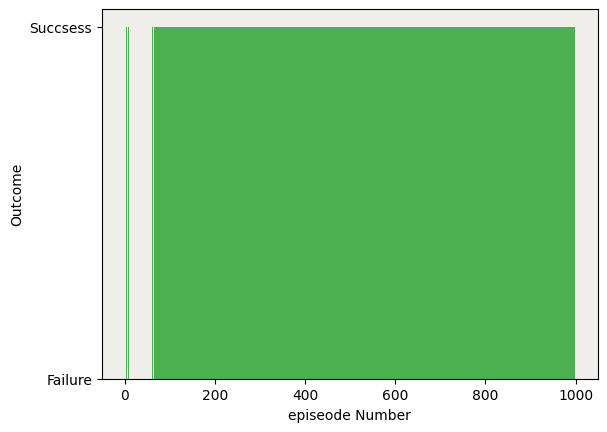

In [267]:
plt.Figure()
plt.xlabel("episeode Number")
plt.ylabel("Outcome")
ax=plt.gca()
ax.set_facecolor("#efeeea")
plt.bar(range(len(outcomes)),outcomes,color="#4caf50",width=1)
plt.show()

In [268]:
# incelediğimizde bir noktaya kadar hiç sucsses yok sonra bir tane çıkıyor ve ilerde devam ediyor 